In [1]:
import tensorflow as tf
from tensorflow import keras 
import os
import numpy as np
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing import image
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
import random
from keras import regularizers
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [2]:
def setup_seed(seed):
    np.random.seed(seed)  
    tf.random.set_seed(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1' 
setup_seed(32) 
random.seed(0)

In [4]:
data = pd.read_excel('Chinese Coal data for coke quality prediction_total table (2026.2.19).xlsx') #数据读取

In [5]:
len(data)

848

In [7]:
remove_index = [5,6,60,74,99,102,105,315,382,387,395,396,397,
398,399,400,401,402,425,426,427,431,432,439,440,488,
490,684,714,729,755,757,758,760,761,808,809,814,820,
824,826,828,832]
data = data.drop(index=remove_index) # 剔除数据预处理部分识别到的异常值，数据数量保持一致

In [8]:
data

,Mad,Ad,Vdaf,"St,d",G,X,Y,a,b,Rmax,...,MnO,Fe2O3,SiO2,Al2O3,TiO2,MCI,CRI,CSR,Coal_name,Unnamed: 36
0,0.72,10.50,25.82,0.49,89.65,10.9,24.50,22.90,143.40,1.190,...,NaN,NaN,NaN,NaN,NaN,NaN,38.51,67.53,LJ(2),焦 煤
1,0.68,10.45,24.24,0.41,87.35,8.2,17.00,23.10,33.20,1.403,...,NaN,NaN,NaN,NaN,NaN,NaN,28.45,78.18,WJ(2),焦 煤
2,0.70,9.28,22.78,1.67,83.00,11.0,21.50,19.30,50.50,1.520,...,NaN,NaN,NaN,NaN,NaN,NaN,23.03,77.06,SLJ,焦 煤
3,0.94,9.65,30.47,0.37,89.80,26.1,19.50,17.50,179.90,1.090,...,NaN,NaN,NaN,NaN,NaN,NaN,42.01,59.22,LF(2),肥煤
4,1.09,8.78,31.52,0.36,88.60,13.6,19.50,19.90,163.90,0.990,...,NaN,NaN,NaN,NaN,NaN,NaN,45.56,63.95,LH(2),肥煤
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
843,2.18,9.48,31.34,0.53,90.00,NaN,17.51,14.34,43.41,NaN,...,NaN,11.070,49.720,16.930,1.190,8.07,40.41,42.74,配合煤,8#
844,0.26,9.12,18.61,NaN,74.00,27.0,10.00,NaN,NaN,NaN,...,0.000,4.868,46.667,38.678,2.570,NaN,32.30,50.00,NaN,焦煤
845,0.50,10.13,20.47,NaN,79.00,30.0,16.00,NaN,NaN,NaN,...,0.017,2.906,46.224,35.382,2.192,NaN,23.20,68.20,NaN,焦煤
846,0.60,10.72,26.82,NaN,90.00,18.5,21.00,NaN,NaN,NaN,...,0.036,5.215,43.356,37.850,2.173,NaN,26.30,61.40,NaN,焦煤


In [31]:
total_value = np.arange(0,len(data)).tolist()   # 全部数据索引

# 先划分验证集 25%
split_val_value = random.sample(total_value[0:len(data)], int(len(total_value)*0.15))

# 训练+测试候选集
split_train_value = []   # 用来存储训练集

for i in total_value:
    if i not in split_val_value:    # 不在验证集里的作为 train+test
        split_train_value.append(i)

# 从 train+test 中再划分测试集 15%
split_test_value = random.sample(split_train_value, int(len(total_value)*0.25))

# 更新训练集 (去掉测试集)
split_train_value = [i for i in split_train_value if i not in split_test_value]

# 取标签 (CRI CSR)
label = np.array(data.iloc[:,-4:-2])

In [32]:
len(split_train_value),len(split_val_value),len(split_test_value)

(484, 120, 201)

In [33]:
coal_imgs_path = r"Coal_images(2026_03_15)_coals_filpped" # 图像数据

coal_Images = [] #存储所有煤数据的图像
coal_ImageList = os.listdir(coal_imgs_path)
coal_ImageList.remove('.ipynb_checkpoints')
coal_ImageList.sort(key=lambda x:int(x[:-4]))
for i in coal_ImageList:
    if i!= '.ipynb_checkpo':
        imagePath = os.path.join(coal_imgs_path,i)   #读取coal图像路径
        coal_Image = image.load_img(imagePath)   #加载图像成jpg格式
        coal_Image = coal_Image.resize((64,64)) #这个是可以调整的一个参数
        img_array = image.img_to_array(coal_Image)   #转换成array格式
        coal_Images.append(img_array)   #保存至列表

In [34]:
# 制作图像的训练集、验证集、测试集
Train = []
Valid = []
Test = []

Train_label = []
Valid_label = []
Test_label = []

# ===== Train =====
for i in split_train_value:
    Train.append(coal_Images[i])
    Train_label.append(label[i])

Train = np.array(Train)
Train_label = np.array(Train_label)

# ===== Validation =====
for i in split_val_value:
    Valid.append(coal_Images[i])
    Valid_label.append(label[i])

Valid = np.array(Valid)
Valid_label = np.array(Valid_label)

# ===== Test =====
for i in split_test_value:
    Test.append(coal_Images[i])
    Test_label.append(label[i])

Test = np.array(Test)
Test_label = np.array(Test_label)

# ===== 图像归一化 =====
Train = Train.astype('float32') / 255
Valid = Valid.astype('float32') / 255
Test  = Test.astype('float32') / 255

# ===== 查看尺寸 =====
print("Train:", Train.shape)
print("Valid:", Valid.shape)
print("Test :", Test.shape)

Train: (484, 64, 64, 3)
Valid: (120, 64, 64, 3)
Test : (201, 64, 64, 3)


In [39]:
model = tf.keras.models.Sequential()   #模型创建，这边尚未在新数据集上对模型结构进行调参，有需要可以进行调整，最终误差在2-3应该是没啥问题
model.add(keras.layers.Conv2D(filters=8,kernel_size=(3,3),kernel_initializer = "he_uniform",padding='same',input_shape=(64,64,3),activation='relu',kernel_regularizer = regularizers.l2(0.0001)))   #卷积层
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.AveragePooling2D()) 
model.add(keras.layers.Conv2D(filters=16,kernel_size=(3,3),kernel_initializer = "he_uniform",padding='same',activation='relu',kernel_regularizer = regularizers.l2(0.0001)))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.AveragePooling2D())
model.add(keras.layers.Flatten())   #将卷积输出打平成一维，方便与全连接层连接
model.add(keras.layers.Dense(200,activation='relu'))   #全连接层
model.add(keras.layers.Dense(100,activation='relu'))   #全连接层
#model.add(keras.layers.Dropout(0.5))   #全连接层
model.add(keras.layers.Dense(2,activation='linear'))   #输出10类别

In [40]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_12 (Conv2D)          (None, 64, 64, 8)         224       
                                                                 
 batch_normalization_12 (Bat  (None, 64, 64, 8)        32        
 chNormalization)                                                
                                                                 
 average_pooling2d_12 (Avera  (None, 32, 32, 8)        0         
 gePooling2D)                                                    
                                                                 
 conv2d_13 (Conv2D)          (None, 32, 32, 16)        1168      
                                                                 
 batch_normalization_13 (Bat  (None, 32, 32, 16)       64        
 chNormalization)                                                
                                                      

In [41]:
opt = tf.keras.optimizers.RMSprop(lr=0.0005,decay=1e-3/300)
checkpoint = tf.keras.callbacks.ModelCheckpoint('./Model_weights_2026_3_15/(2026_3_15).{val_loss:02f}.h5', monitor='val_loss', verbose=3,save_best_only=True,mode='min',period=1) #保存验证集上的最优权重
callbacks_list = [checkpoint]

In [42]:
# random seed
model.compile(loss='mean_absolute_error',optimizer=opt)
model.fit(x=Train,y=Train_label,validation_data=(Valid,Valid_label),epochs=5000,batch_size=128,callbacks=callbacks_list,verbose=1)

Epoch 1/5000
3/4 [=====================>........] - ETA: 0s - loss: 35.1742
Epoch 1: val_loss improved from inf to 44.34108, saving model to ./Model_weights_2026_3_15/(2026_3_15).44.341076.h5
4/4 [==============================] - 4s 408ms/step - loss: 31.4332 - val_loss: 44.3411
Epoch 2/5000
4/4 [==============================] - ETA: 0s - loss: 9.0551 
Epoch 2: val_loss improved from 44.34108 to 44.27443, saving model to ./Model_weights_2026_3_15/(2026_3_15).44.274433.h5
4/4 [==============================] - 1s 158ms/step - loss: 9.0551 - val_loss: 44.2744
Epoch 3/5000
3/4 [=====================>........] - ETA: 0s - loss: 8.0721
Epoch 3: val_loss improved from 44.27443 to 44.22391, saving model to ./Model_weights_2026_3_15/(2026_3_15).44.223911.h5
4/4 [==============================] - 1s 164ms/step - loss: 8.0923 - val_loss: 44.2239
Epoch 4/5000
3/4 [=====================>........] - ETA: 0s - loss: 8.0254
Epoch 4: val_loss improved from 44.22391 to 44.17778, saving model to ./Mod

2026-03-15 11:58:33.587470: W tensorflow/core/data/root_dataset.cc:247] Optimization loop failed: CANCELLED: Operation was cancelled



Epoch 147: val_loss did not improve from 5.30335
4/4 [==============================] - 0s 116ms/step - loss: 5.8037 - val_loss: 6.2823
Epoch 148/5000
4/4 [==============================] - ETA: 0s - loss: 5.7330
Epoch 148: val_loss did not improve from 5.30335
4/4 [==============================] - 0s 130ms/step - loss: 5.7330 - val_loss: 7.1990
Epoch 149/5000
3/4 [=====================>........] - ETA: 0s - loss: 5.9515
Epoch 149: val_loss did not improve from 5.30335
4/4 [==============================] - 0s 115ms/step - loss: 5.9484 - val_loss: 5.6914
Epoch 150/5000
3/4 [=====================>........] - ETA: 0s - loss: 5.8969
Epoch 150: val_loss improved from 5.30335 to 5.26380, saving model to ./Model_weights_2026_3_15/(2026_3_15).5.263796.h5
4/4 [==============================] - 1s 177ms/step - loss: 5.7914 - val_loss: 5.2638
Epoch 151/5000
3/4 [=====================>........] - ETA: 0s - loss: 5.8759
Epoch 151: val_loss did not improve from 5.26380
4/4 [======================

2026-03-15 11:59:00.367151: W tensorflow/core/data/root_dataset.cc:247] Optimization loop failed: CANCELLED: Operation was cancelled



Epoch 213: val_loss did not improve from 4.99862
4/4 [==============================] - 0s 104ms/step - loss: 5.4932 - val_loss: 6.2150
Epoch 214/5000
3/4 [=====================>........] - ETA: 0s - loss: 5.4692
Epoch 214: val_loss did not improve from 4.99862
4/4 [==============================] - 0s 112ms/step - loss: 5.4726 - val_loss: 5.4751
Epoch 215/5000
3/4 [=====================>........] - ETA: 0s - loss: 5.3859
Epoch 215: val_loss did not improve from 4.99862
4/4 [==============================] - 0s 117ms/step - loss: 5.4050 - val_loss: 5.3320
Epoch 216/5000
3/4 [=====================>........] - ETA: 0s - loss: 5.4760
Epoch 216: val_loss did not improve from 4.99862
4/4 [==============================] - 0s 126ms/step - loss: 5.3973 - val_loss: 5.1141
Epoch 217/5000
3/4 [=====================>........] - ETA: 0s - loss: 5.0832
Epoch 217: val_loss did not improve from 4.99862
4/4 [==============================] - 0s 103ms/step - loss: 5.1443 - val_loss: 6.5241
Epoch 218/5

...

2026-03-15 12:19:01.603165: W tensorflow/core/data/root_dataset.cc:247] Optimization loop failed: CANCELLED: Operation was cancelled



Epoch 3473: val_loss did not improve from 4.77938
4/4 [==============================] - 0s 103ms/step - loss: 0.8486 - val_loss: 7.1849
Epoch 3474/5000
3/4 [=====================>........] - ETA: 0s - loss: 0.8746
Epoch 3474: val_loss did not improve from 4.77938
4/4 [==============================] - 0s 117ms/step - loss: 0.9263 - val_loss: 8.0900
Epoch 3475/5000
3/4 [=====================>........] - ETA: 0s - loss: 1.1590
Epoch 3475: val_loss did not improve from 4.77938
4/4 [==============================] - 0s 119ms/step - loss: 1.1031 - val_loss: 6.2366
Epoch 3476/5000
3/4 [=====================>........] - ETA: 0s - loss: 0.8555
Epoch 3476: val_loss did not improve from 4.77938
4/4 [==============================] - 0s 109ms/step - loss: 0.8730 - val_loss: 8.6866
Epoch 3477/5000
3/4 [=====================>........] - ETA: 0s - loss: 0.8848
Epoch 3477: val_loss did not improve from 4.77938
4/4 [==============================] - 0s 115ms/step - loss: 0.9000 - val_loss: 5.7244
Ep

2026-03-15 12:19:56.531152: W tensorflow/core/data/root_dataset.cc:247] Optimization loop failed: CANCELLED: Operation was cancelled



Epoch 3622: val_loss did not improve from 4.77938
4/4 [==============================] - 0s 118ms/step - loss: 0.7841 - val_loss: 5.2262
Epoch 3623/5000
4/4 [==============================] - ETA: 0s - loss: 1.1855
Epoch 3623: val_loss did not improve from 4.77938
4/4 [==============================] - 0s 108ms/step - loss: 1.1855 - val_loss: 5.8478
Epoch 3624/5000
3/4 [=====================>........] - ETA: 0s - loss: 0.9371
Epoch 3624: val_loss did not improve from 4.77938
4/4 [==============================] - 0s 110ms/step - loss: 0.9739 - val_loss: 5.2809
Epoch 3625/5000
3/4 [=====================>........] - ETA: 0s - loss: 0.7720
Epoch 3625: val_loss did not improve from 4.77938
4/4 [==============================] - 0s 117ms/step - loss: 0.7685 - val_loss: 5.7379
Epoch 3626/5000
3/4 [=====================>........] - ETA: 0s - loss: 0.9063
Epoch 3626: val_loss did not improve from 4.77938
4/4 [==============================] - 0s 106ms/step - loss: 0.8604 - val_loss: 6.4446
Ep


KeyboardInterrupt



In [43]:
model = tf.keras.models.load_model('./Model_weights_2026_3_15/(2026_3_15).4.779379.h5')  #加载最优权重

In [44]:
def compute_abs_error(predict,label):
    error = predict-np.array(label)
    return abs(error).mean()

In [45]:
predict = model.predict(Test)

7/7 [==============================] - 1s 24ms/step


In [46]:
CRI_error = compute_abs_error(predict[:,0],Test_label[:,0])
CSR_error = compute_abs_error(predict[:,1],Test_label[:,1])
Total_error = compute_abs_error(predict,Test_label)

CRI_RMSE_error = np.sqrt(mean_squared_error(predict[:,0],Test_label[:,0]))
CSR_RMSE_error = np.sqrt(mean_squared_error(predict[:,1],Test_label[:,1]))
 
CRI_R2_score = r2_score(predict[:,0],Test_label[:,0])
CSR_R2_score = r2_score(predict[:,1],Test_label[:,1])

print("CRI Abs error: {}".format(CRI_error))
print("CSR Abs error: {}".format(CSR_error))
print("CRI MSE error: {}".format(CRI_RMSE_error))
print("CSR MSE error: {}".format(CSR_RMSE_error))
print("Total error: {}".format(Total_error))

print("CRI_R2_score:{}".format(CRI_R2_score))
print("CSR_R2_score:{}".format(CSR_R2_score))

CRI Abs error: 4.587152226006807
CSR Abs error: 5.742164218200379
CRI MSE error: 6.229918388625903
CSR MSE error: 8.010741301943986
Total error: 5.164658222103593
CRI_R2_score:-0.22678665545065324
CSR_R2_score:0.014219740905910827


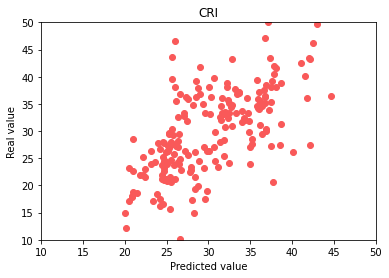

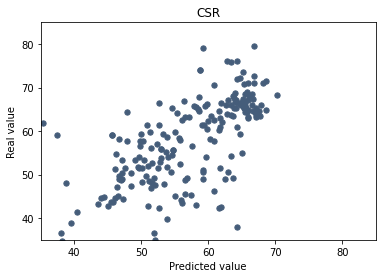

In [47]:
plt.figure()
plt.xlim((10,50))
plt.ylim((10,50))
plt.title('CRI')
plt.scatter(predict[:,0],Test_label[:,0],c='#f95959',marker='o')
plt.xlabel("Predicted value")
plt.ylabel("Real value")
plt.show()

plt.figure()
plt.xlim((35,85))
plt.ylim((35,85))
plt.title('CSR')
plt.scatter(predict[:,1],Test_label[:,1],s=28,c='#455d7a',marker='o')
plt.xlabel("Predicted value")
plt.ylabel("Real value")
plt.show()